In [1]:
!pip install torch tensorflow ultralytics pillow matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 50.2 MB/s eta 0:00:00


In [2]:
import torch
import tensorflow as tf
from ultralytics import YOLO
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import shutil
import gc

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# 0. Verificação da GPU

In [3]:
if tf.test.gpu_device_name():
    print("GPU found!")
else:
    print("GPU not found!")
    
print(torch.cuda.is_available())
print(torch.cuda.device_count())

GPU found!
True
1


I0000 00:00:1773259677.591295      55 gpu_device.cc:2019] Created device /device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [5]:
!nvidia-smi

Wed Mar 11 20:08:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   30C    P0             31W /  250W |     259MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
# Código para, caso a memória cache esteja cheia, esvaziar
gc.collect()
torch.cuda.empty_cache()

# 1. Configurando ambiente de treinamento

In [6]:
%%writefile dataset.yaml

# Configuração do arquivo yaml onde tem os paths e configurações gerais que serão utilizadas
train: "/kaggle/input/datasets/nicodenico/microscopia/treino/images/Train"
test: "/kaggle/input/datasets/nicodenico/microscopia/teste/images/Test"
val: "/kaggle/input/datasets/nicodenico/microscopia/val/images/val"

names:
  0: mono_flakes

Overwriting dataset.yaml


# 2. Treinando

Para entender melhor os parâmetros e arquitetura da rede é possível ler a [documentação da Ultralytics](https://docs.ultralytics.com/pt/modes/train/#musgd-optimizer)

In [7]:
model = YOLO("yolov8s-seg.pt")   # pode ser n, s, m, l, x, mas é necessário considerar underfit e overfit com base no modelo

model.train(
    data="/kaggle/working/dataset.yaml",
    rect = False,
    seed = 2026, # Para reprodutibilidade
    imgsz=1920,
    batch= 1,
    epochs=50,
    augment=True, # Ativa vários parâmetros de aumento de dados e hiperparâmetros, possível encontrar na documentação
    degrees=30, # Gira a imagem aleatoriamente em até 15 graus
    fliplr=0.5, # Inverte a imagem horizontalmente com 50% de probabilidade
    flipud=0.5, # Inverte a imagem verticamente com 50% de probabilidade
    save_period = 5, # A cada 5 épocas salva o modelo
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset.yaml, degrees=30, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1920, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:839: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
       2/50      13.6G     0.5371     0.6456      16.95     0.5258          0         34       1920: 91% ━━━━━━━━━━╸─ 139/152 4.0it/s 55.3s<3.3ss


KeyboardInterrupt: 

In [ ]:
# Código para, caso o treinamento seja interrompido, voltar a treinar

model = YOLO("/kaggle/working/runs/segment/train6/weights/best.pt")  # caminho do modelo

model.train(
    data="dataset.yaml",
    resume=True
)

# 3. Testando e salvando

A documentação dessa parte do código pode ser encontrada no [site do ultralytics](https://docs.ultralytics.com/pt/modes/predict/#working-with-results)

In [43]:
model = YOLO("/kaggle/input/datasets/nicodenico/microscopia/runs/segment/modelos_treinados/modelo_2/weights/best.pt")  # caminho do best.pt do modelo

In [48]:
%%writefile dataset_teste.yaml

# Mudando o teste com o val para avaliar o modelo com a biblioteca

train: "/kaggle/input/datasets/nicodenico/microscopia/treino/images/Train"
test: "/kaggle/input/datasets/nicodenico/microscopia/val/images"
val: "/kaggle/input/datasets/nicodenico/microscopia/teste/images/Test"


names:
  0: mono_flakes

Overwriting dataset_teste.yaml


In [49]:
metrics = model.val(
    data="dataset_teste.yaml",
    imgsz=1920,
    conf=0.001,
    plots=True
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
val: Fast image access ✅ (ping: 1.5±0.4 ms, read: 99.0±26.2 MB/s, size: 51.3 KB)
val: Scanning /kaggle/input/datasets/nicodenico/microscopia/teste/labels/Test... 10 images, 0 backgrounds, 4 corrupt: 100% ━━━━━━━━━━━━ 10/10 214.9it/s 0.0s
val: /kaggle/input/datasets/nicodenico/microscopia/teste/images/Test/HETMDB30_Spot1_1_nivelado_classified.png: ignoring corrupt image/label: Label class 1 exceeds dataset class count 1. Possible class labels are 0-0
val: /kaggle/input/datasets/nicodenico/microscopia/teste/images/Test/HETMDB30_Spot5_3_nivelado_classified.png: ignoring corrupt image/label: Label class 1 exceeds dataset class count 1. Possible class labels are 0-0
val: /kaggle/input/datasets/nicodenico/microscopia/teste/images/Test/HETMDB30_Spot5_4_nivelado_classified.png: ignoring corrupt image/label: Label class 1 exceeds dataset class count 1. Possible class labels are 0-0
val: /kaggle/input/datasets/nic

In [56]:
# F1 curve
f1_curve = metrics.curves_results[1][1][0]

# thresholds de confiança
conf_thresholds = metrics.curves_results[1][0]

best_index = np.argmax(f1_curve)
best_conf = conf_thresholds[best_index]
best_f1 = f1_curve[best_index]

print("Best confidence threshold:", best_conf)
print("Best F1 score:", best_f1)

Best confidence threshold: 0.12912912912912913
Best F1 score: 0.5620481718784912


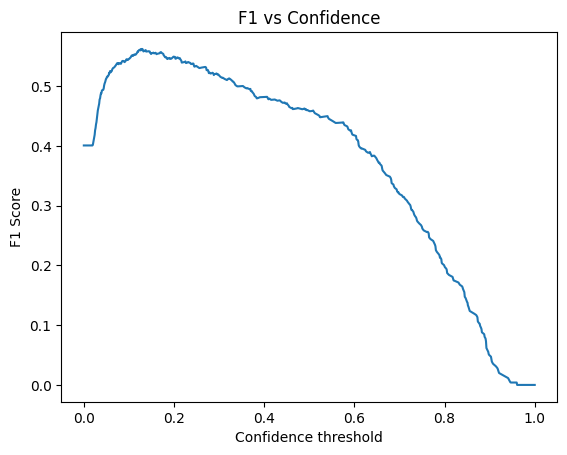

In [57]:
plt.plot(conf_thresholds, f1_curve)
plt.xlabel("Confidence threshold")
plt.ylabel("F1 Score")
plt.title("F1 vs Confidence")
plt.show()

In [59]:
threshold = 0.12912912912912913 # threshold calculado

In [60]:
# Predição das imagens de teste para avaliação visual e entendimento do modeo
folder_path = "/kaggle/input/datasets/nicodenico/microscopia/teste/images/Test"

model.predict(
    folder_path, 
    conf = threshold,
    save=True, 
    show_labels=False,  
    show_conf=False,
)


image 1/10 /kaggle/input/datasets/nicodenico/microscopia/teste/images/Test/HETMDB30_Spot1_1_nivelado_classified.png: 1440x1920 49 mono_flakess, 1398.7ms
image 2/10 /kaggle/input/datasets/nicodenico/microscopia/teste/images/Test/HETMDB30_Spot5_3_nivelado_classified.png: 1440x1920 127 mono_flakess, 1287.1ms
image 3/10 /kaggle/input/datasets/nicodenico/microscopia/teste/images/Test/HETMDB30_Spot5_4_nivelado_classified.png: 1440x1920 147 mono_flakess, 1135.8ms
image 4/10 /kaggle/input/datasets/nicodenico/microscopia/teste/images/Test/HETMDB30_Spot5_8_nivelado_classified.png: 1440x1920 130 mono_flakess, 1185.4ms
image 5/10 /kaggle/input/datasets/nicodenico/microscopia/teste/images/Test/HETMDB30_Spot5_9_nivelado_classified.png: 1440x1920 151 mono_flakess, 1133.8ms
image 6/10 /kaggle/input/datasets/nicodenico/microscopia/teste/images/Test/HETMDB30_Spot6_6_nivelado_classified.png: 1440x1920 93 mono_flakess, 1110.0ms
image 7/10 /kaggle/input/datasets/nicodenico/microscopia/teste/images/Test/HE

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: ultralytics.engine.results.Masks object
 names: {0: 'mono_flakes'}
 obb: None
 orig_img: array([[[200, 200, 200],
         [200, 200, 200],
         [200, 200, 200],
         ...,
         [200, 200, 200],
         [200, 200, 200],
         [200, 200, 200]],
 
        [[200, 200, 200],
         [200, 200, 200],
         [200, 200, 200],
         ...,
         [200, 200, 200],
         [200, 200, 200],
         [200, 200, 200]],
 
        [[200, 200, 200],
         [200, 200, 200],
         [200, 200, 200],
         ...,
         [200, 200, 200],
         [200, 200, 200],
         [200, 200, 200]],
 
        ...,
 
        [[  0,   0, 255],
         [  0,   0, 255],
         [  0,   0, 255],
         ...,
         [  0, 255,   0],
         [  0, 255,   0],
         [  0, 255,   0]],
 
        [[  0,   0, 255],
         [  0,   0, 255],
         [  0,   0

In [61]:
metrics = model.val(
    data="dataset_teste.yaml",
    imgsz= 1920,
    conf= threshold,
    plots= True
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
val: Fast image access ✅ (ping: 1.0±0.8 ms, read: 83.1±42.8 MB/s, size: 50.0 KB)
val: Scanning /kaggle/input/datasets/nicodenico/microscopia/teste/labels/Test... 10 images, 0 backgrounds, 4 corrupt: 100% ━━━━━━━━━━━━ 10/10 198.1it/s 0.1s
val: /kaggle/input/datasets/nicodenico/microscopia/teste/images/Test/HETMDB30_Spot1_1_nivelado_classified.png: ignoring corrupt image/label: Label class 1 exceeds dataset class count 1. Possible class labels are 0-0
val: /kaggle/input/datasets/nicodenico/microscopia/teste/images/Test/HETMDB30_Spot5_3_nivelado_classified.png: ignoring corrupt image/label: Label class 1 exceeds dataset class count 1. Possible class labels are 0-0
val: /kaggle/input/datasets/nicodenico/microscopia/teste/images/Test/HETMDB30_Spot5_4_nivelado_classified.png: ignoring corrupt image/label: Label class 1 exceeds dataset class count 1. Possible class labels are 0-0
val: /kaggle/input/datasets/nic

In [63]:
shutil.make_archive("resultados", "zip", "/kaggle/working/runs/segment/predict3")
shutil.make_archive("resultados_metricas", "zip", "/kaggle/working/runs/segment/val7")

'/kaggle/working/resultados_metricas.zip'

In [ ]:
# Deleta a pasta working para limpar a memória do Kaggle notebook (PERIGOSO!!)
!rm -rf /kaggle/working/*